In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# CELL 1 ─ Install Required Packages

import subprocess, sys

packages = [
    'scikit-image', 'scikit-learn', 'pillow',
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'tqdm'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('All packages installed')

All packages installed


In [3]:
# CELL 2 ─ Imports

import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image
warnings.filterwarnings('ignore')

# ── Classical ML ──────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from skimage.feature import hog

# ── PyTorch ───────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler   # Automatic Mixed Precision
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import torchvision.models as tv_models            # renamed → no shadowing risk
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── Reproducibility ───────────────────────────
np.random.seed(42)
torch.manual_seed(42)

# ── GPU Setup ─────────────────────────────────
if not torch.cuda.is_available():
    raise EnvironmentError(
        'CUDA not available. Check your GPU driver / CUDA toolkit installation.'
    )

torch.cuda.manual_seed_all(42)
torch.backends.cudnn.benchmark = True   # speed boost for fixed input size
DEVICE = torch.device('cuda')

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
print(f'GPU      : {torch.cuda.get_device_name(0)}')
print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  : 2.5.1
CUDA     : 11.8
GPU      : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM     : 6.4 GB


In [4]:
# CELL 3 ─ Dataset Path & Class Discovery

DATASET_DIR = Path('PlantVillage')

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATASET_DIR.resolve()}\n'
        'Download from: https://www.kaggle.com/datasets/emmarex/plantdisease'
    )

# Support both flat layout and nested train/ layout
DATA_ROOT = DATASET_DIR / 'train' if (DATASET_DIR / 'train').exists() else DATASET_DIR

CLASSES    = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

print(f'Data root  : {DATA_ROOT}')
print(f'Num classes: {NUM_CLASSES}')
total_images = sum(len(list((DATA_ROOT/c).glob('*.*'))) for c in CLASSES)
print(f'Total images : {total_images:,}')
print()
for i, cls in enumerate(CLASSES, 1):
    n = len(list((DATA_ROOT / cls).glob('*.*')))
    print(f'  {i:2d}. {cls:<45} {n:>5} images')

Data root  : PlantVillage
Num classes: 15
Total images : 20,638

   1. Pepper__bell___Bacterial_spot                   997 images
   2. Pepper__bell___healthy                         1478 images
   3. Potato___Early_blight                          1000 images
   4. Potato___Late_blight                           1000 images
   5. Potato___healthy                                152 images
   6. Tomato_Bacterial_spot                          2127 images
   7. Tomato_Early_blight                            1000 images
   8. Tomato_Late_blight                             1909 images
   9. Tomato_Leaf_Mold                                952 images
  10. Tomato_Septoria_leaf_spot                      1771 images
  11. Tomato_Spider_mites_Two_spotted_spider_mite    1676 images
  12. Tomato__Target_Spot                            1404 images
  13. Tomato__Tomato_YellowLeaf__Curl_Virus          3208 images
  14. Tomato__Tomato_mosaic_virus                     373 images
  15. Tomato_healthy     

In [5]:
# CELL 4 ─ Pipeline A: Load images directly as
#           64×64 grayscale  (memory-efficient)

ML_IMG_SIZE = (64, 64)

def load_for_ml(data_root, classes, class_to_idx, size=ML_IMG_SIZE):
    X, y = [], []
    for cls in tqdm(classes, desc='Loading (grayscale 64×64)'):
        for img_path in (data_root / cls).glob('*.*'):
            try:
                img = Image.open(img_path).convert('L').resize(size)   # L = grayscale
                X.append(np.array(img, dtype=np.uint8))
                y.append(class_to_idx[cls])
            except Exception as e:
                print(f'  Skip {img_path.name}: {e}')
    return np.array(X), np.array(y)

X_ml, y_ml = load_for_ml(DATA_ROOT, CLASSES, CLASS_TO_IDX)
print(f'\n Loaded  : {X_ml.shape}  (N × H × W)')

# Stratified 80/20 split
X_tr_ml, X_te_ml, y_tr_ml, y_te_ml = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)
print(f'Train   : {len(X_tr_ml):,}   Test: {len(X_te_ml):,}')

Loading (grayscale 64×64): 100%|███████████████████████████████████████████████████████| 15/15 [00:53<00:00,  3.57s/it]


 Loaded  : (20638, 64, 64)  (N × H × W)
Train   : 16,510   Test: 4,128


In [6]:
# CELL 5 ─ HOG Feature Extraction

HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys'
)

def extract_hog(images, desc='HOG'):
    return np.array([hog(img, **HOG_PARAMS) for img in tqdm(images, desc=desc)])

print('Extracting HOG features...')
X_tr_hog = extract_hog(X_tr_ml, 'HOG train')
X_te_hog = extract_hog(X_te_ml, 'HOG test')
print(f'HOG feature vector length: {X_tr_hog.shape[1]}')

Extracting HOG features...


HOG test: 100%|███████████████████████████████████████████████████████████████████| 4128/4128 [00:14<00:00, 287.81it/s]

HOG feature vector length: 1764


In [7]:
# CELL 6 ─ StandardScaler + PCA (95% variance)

scaler_ml = StandardScaler()
X_tr_sc   = scaler_ml.fit_transform(X_tr_hog)
X_te_sc   = scaler_ml.transform(X_te_hog)

pca = PCA(n_components=0.95, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)

print(f'Original features : {X_tr_sc.shape[1]}')
print(f'After PCA         : {X_tr_pca.shape[1]}')
print(f'Variance retained : {pca.explained_variance_ratio_.sum():.4f}')

Original features : 1764
After PCA         : 509
Variance retained : 0.9503


In [8]:
# CELL 7 ─ Model A1: KNN (Baseline)

print('Training KNN...')
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_tr_pca, y_tr_ml)
print('KNN training completed')          

y_pred_knn = knn.predict(X_te_pca)

knn_results = {
    'accuracy' : accuracy_score(y_te_ml, y_pred_knn),
    'precision': precision_score(y_te_ml, y_pred_knn, average='weighted', zero_division=0),
    'recall'   : recall_score   (y_te_ml, y_pred_knn, average='weighted', zero_division=0),
    'f1'       : f1_score       (y_te_ml, y_pred_knn, average='weighted', zero_division=0),
    'y_true'   : y_te_ml,
    'y_pred'   : y_pred_knn,
}

print(f"\nKNN  |  Acc {knn_results['accuracy']:.4f}  "
      f"P {knn_results['precision']:.4f}  "
      f"R {knn_results['recall']:.4f}  "
      f"F1 {knn_results['f1']:.4f}")

Training KNN...
KNN training completed

KNN  |  Acc 0.6320  P 0.6527  R 0.6320  F1 0.6159


In [9]:
# CELL 8 ─ Model A2: MLP (ANN)

print('Training MLP...')
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)
mlp.fit(X_tr_pca, y_tr_ml)
print('MLP training completed')

y_pred_mlp = mlp.predict(X_te_pca)

mlp_results = {
    'accuracy' : accuracy_score(y_te_ml, y_pred_mlp),
    'precision': precision_score(y_te_ml, y_pred_mlp, average='weighted', zero_division=0),
    'recall'   : recall_score   (y_te_ml, y_pred_mlp, average='weighted', zero_division=0),
    'f1'       : f1_score       (y_te_ml, y_pred_mlp, average='weighted', zero_division=0),
    'y_true'   : y_te_ml,
    'y_pred'   : y_pred_mlp,
}

print(f"\nMLP  |  Acc {mlp_results['accuracy']:.4f}  "
      f"P {mlp_results['precision']:.4f}  "
      f"R {mlp_results['recall']:.4f}  "
      f"F1 {mlp_results['f1']:.4f}")

Training MLP...
MLP training completed

MLP  |  Acc 0.6710  P 0.6643  R 0.6710  F1 0.6669


In [10]:
# CELL 9 ─ DataLoaders (ImageFolder — lazy)

DL_IMG_SIZE  = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 4        

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Two ImageFolder instances share the same directory but different transforms
ds_train_full = ImageFolder(str(DATA_ROOT), transform=train_transform)
ds_test_full  = ImageFolder(str(DATA_ROOT), transform=test_transform)

# Stratified 80/20 split (same indices as ML pipeline for fair comparison)
all_targets = ds_train_full.targets
all_indices = list(range(len(all_targets)))
tr_idx, te_idx = train_test_split(
    all_indices, test_size=0.2, random_state=42, stratify=all_targets
)

train_ds = Subset(ds_train_full, tr_idx)
test_ds  = Subset(ds_test_full,  te_idx)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

print(f' Train batches : {len(train_loader)} × {BATCH_SIZE}')
print(f' Test  batches : {len(test_loader)} × {BATCH_SIZE}')
print(f' Classes       : {ds_train_full.classes[:5]} …')

 Train batches : 516 × 32
 Test  batches : 129 × 32
 Classes       : ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy'] …


In [11]:
# CELL 10 ─ GPU Trainer with AMP

class GPUTrainer:
    def __init__(self, model, train_loader, test_loader, device,
                 lr=1e-3, weight_decay=1e-4):
        self.model        = model.to(device)
        self.train_loader = train_loader
        self.test_loader  = test_loader
        self.device       = device
        self.criterion    = nn.CrossEntropyLoss()
        self.optimizer    = optim.AdamW(model.parameters(), lr=lr,
                                        weight_decay=weight_decay)
        # FIX: monitor val_loss, not train_loss
        self.scheduler    = ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )
        self.amp_scaler   = GradScaler()           # AMP gradient scaler
        self.history      = {'train_loss': [], 'val_acc': [], 'val_loss': []}
        self.best_acc     = 0.0

    # single training epoch 
    def _train_epoch(self):
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in tqdm(self.train_loader, desc='  train', leave=False):
            imgs = imgs.to(self.device, non_blocking=True)
            lbls = lbls.to(self.device, non_blocking=True)
            self.optimizer.zero_grad(set_to_none=True)   
            with autocast():                             
                out  = self.model(imgs)
                loss = self.criterion(out, lbls)
            self.amp_scaler.scale(loss).backward()
            self.amp_scaler.step(self.optimizer)
            self.amp_scaler.update()
            total_loss += loss.item()
            correct    += (out.argmax(1) == lbls).sum().item()
            total      += lbls.size(0)
        return total_loss / len(self.train_loader), 100 * correct / total

    # evaluation 
    def _evaluate(self):
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, lbls in tqdm(self.test_loader, desc='  eval ', leave=False):
                imgs = imgs.to(self.device, non_blocking=True)
                lbls = lbls.to(self.device, non_blocking=True)
                with autocast():
                    out  = self.model(imgs)
                    loss = self.criterion(out, lbls)
                total_loss += loss.item()
                preds = out.argmax(1)
                correct += (preds == lbls).sum().item()
                total   += lbls.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(lbls.cpu().numpy())
        avg_loss = total_loss / len(self.test_loader)
        acc      = 100 * correct / total
        return avg_loss, acc, np.array(all_preds), np.array(all_labels)

    # full training loop 
    def train(self, epochs=15):
        name = self.model.__class__.__name__
        print(f'\nTraining {name} on {self.device} for {epochs} epochs…')
        for epoch in range(1, epochs + 1):
            tr_loss, tr_acc       = self._train_epoch()
            val_loss, val_acc, _, _ = self._evaluate()
            self.scheduler.step(val_loss)           
            self.history['train_loss'].append(tr_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_loss'].append(val_loss)
            if val_acc > self.best_acc:
                self.best_acc = val_acc
            if epoch % 3 == 0 or epoch == 1:
                print(f'  Ep {epoch:3d}/{epochs}  '
                      f'loss={tr_loss:.4f}  tr_acc={tr_acc:.1f}%  '
                      f'val_acc={val_acc:.1f}%  [best={self.best_acc:.1f}%]')
        print(f'{name} done. Best val acc = {self.best_acc:.2f}%')
        return self.history

    # ── final predictions ───────────────────
    def predict(self):
        _, acc, preds, labels = self._evaluate()
        return acc, preds, labels

print(' GPUTrainer defined')

 GPUTrainer defined


In [12]:
# CELL 11 ─ Model B1: ResNet50

torch.cuda.empty_cache()

resnet50 = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
for p in resnet50.parameters(): p.requires_grad = False     

# Unfreeze layer4 + classifier for fine-tuning
for p in resnet50.layer4.parameters(): p.requires_grad = True

# Replace head
in_feat = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(in_feat, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 256),     nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

trainer_resnet = GPUTrainer(resnet50, train_loader, test_loader, DEVICE)
hist_resnet    = trainer_resnet.train(epochs=20)

resnet_acc, resnet_preds, resnet_true = trainer_resnet.predict()
resnet_results = {
    'accuracy' : resnet_acc / 100,
    'precision': precision_score(resnet_true, resnet_preds, average='weighted', zero_division=0),
    'recall'   : recall_score   (resnet_true, resnet_preds, average='weighted', zero_division=0),
    'f1'       : f1_score       (resnet_true, resnet_preds, average='weighted', zero_division=0),
    'y_true'   : resnet_true,
    'y_pred'   : resnet_preds,
}
print(f"\nResNet50 |  Acc {resnet_results['accuracy']:.4f}  "
      f"P {resnet_results['precision']:.4f}  "
      f"R {resnet_results['recall']:.4f}  "
      f"F1 {resnet_results['f1']:.4f}")


Training ResNet on cuda for 20 epochs…


  Ep   1/20  loss=0.7891  tr_acc=74.7%  val_acc=93.8%  [best=93.8%]


  Ep   3/20  loss=0.2139  tr_acc=93.8%  val_acc=97.9%  [best=97.9%]


  Ep   6/20  loss=0.1093  tr_acc=96.8%  val_acc=97.9%  [best=98.5%]


  Ep   9/20  loss=0.0884  tr_acc=97.6%  val_acc=98.4%  [best=98.5%]


  Ep  12/20  loss=0.0672  tr_acc=98.0%  val_acc=98.5%  [best=99.1%]


  Ep  15/20  loss=0.0562  tr_acc=98.4%  val_acc=98.9%  [best=99.1%]


  Ep  18/20  loss=0.0290  tr_acc=99.2%  val_acc=99.1%  [best=99.3%]


ResNet done. Best val acc = 99.39%



ResNet50 |  Acc 0.9872  P 0.9877  R 0.9872  F1 0.9872


In [13]:
#Fine-tune: unfreeze ALL backbone layers
print("\n ResNet50 Fine-tuning (10 epochs, lr=1e-5)")
for p in resnet50.parameters():
    p.requires_grad = True          

# Re-create trainer with a much smaller lr
trainer_resnet_ft = GPUTrainer(resnet50, train_loader, test_loader, DEVICE,
                               lr=1e-5, weight_decay=1e-4)
hist_resnet_ft = trainer_resnet_ft.train(epochs=10)

resnet_acc, resnet_preds, resnet_true = trainer_resnet_ft.predict()
resnet_results = {
    'accuracy'  : resnet_acc / 100,
    'precision' : precision_score(resnet_true, resnet_preds, average='weighted', zero_division=0),
    'recall'    : recall_score   (resnet_true, resnet_preds, average='weighted', zero_division=0),
    'f1'        : f1_score       (resnet_true, resnet_preds, average='weighted', zero_division=0),
    'y_true'    : resnet_true,
    'y_pred'    : resnet_preds,
}
print(f"\nResNet50 (after fine-tune) | Acc {resnet_results['accuracy']:.4f} "
      f"P {resnet_results['precision']:.4f} "
      f"R {resnet_results['recall']:.4f} "
      f"F1 {resnet_results['f1']:.4f}")


 ResNet50 Fine-tuning (10 epochs, lr=1e-5)

Training ResNet on cuda for 10 epochs…


  Ep   1/10  loss=0.0205  tr_acc=99.4%  val_acc=99.6%  [best=99.6%]


  Ep   3/10  loss=0.0125  tr_acc=99.6%  val_acc=99.4%  [best=99.6%]


  Ep   6/10  loss=0.0136  tr_acc=99.6%  val_acc=99.6%  [best=99.6%]


  Ep   9/10  loss=0.0102  tr_acc=99.7%  val_acc=99.7%  [best=99.7%]


ResNet done. Best val acc = 99.69%



ResNet50 (after fine-tune) | Acc 0.9959 P 0.9959 R 0.9959 F1 0.9959


In [14]:
# CELL 12 ─ Model B2: MobileNetV2

torch.cuda.empty_cache()     

mobilenet = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
for p in mobilenet.parameters(): p.requires_grad = False

# Unfreeze last conv block + classifier
for p in mobilenet.features[-1].parameters(): p.requires_grad = True

in_feat = mobilenet.classifier[1].in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_feat, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

trainer_mobile = GPUTrainer(mobilenet, train_loader, test_loader, DEVICE, lr=1e-3)
hist_mobile    = trainer_mobile.train(epochs=20)

mobile_acc, mobile_preds, mobile_true = trainer_mobile.predict()
mobile_results = {
    'accuracy' : mobile_acc / 100,
    'precision': precision_score(mobile_true, mobile_preds, average='weighted', zero_division=0),
    'recall'   : recall_score   (mobile_true, mobile_preds, average='weighted', zero_division=0),
    'f1'       : f1_score       (mobile_true, mobile_preds, average='weighted', zero_division=0),
    'y_true'   : mobile_true,
    'y_pred'   : mobile_preds,
}
print(f"\nMobileV2 |  Acc {mobile_results['accuracy']:.4f}  "
      f"P {mobile_results['precision']:.4f}  "
      f"R {mobile_results['recall']:.4f}  "
      f"F1 {mobile_results['f1']:.4f}")


Training MobileNetV2 on cuda for 20 epochs…


  Ep   1/20  loss=0.5458  tr_acc=82.4%  val_acc=91.3%  [best=91.3%]


  Ep   3/20  loss=0.2817  tr_acc=90.5%  val_acc=94.0%  [best=94.0%]


  Ep   6/20  loss=0.2174  tr_acc=92.6%  val_acc=95.1%  [best=95.8%]


  Ep   9/20  loss=0.1948  tr_acc=93.5%  val_acc=96.1%  [best=96.1%]


  Ep  12/20  loss=0.1783  tr_acc=93.9%  val_acc=96.4%  [best=96.4%]


  Ep  15/20  loss=0.1635  tr_acc=94.5%  val_acc=96.6%  [best=96.6%]


  Ep  18/20  loss=0.1497  tr_acc=95.2%  val_acc=96.4%  [best=96.7%]


MobileNetV2 done. Best val acc = 96.85%



MobileV2 |  Acc 0.9675  P 0.9679  R 0.9675  F1 0.9674


In [15]:
# Fine-tune: unfreeze ALL backbone layers
print("\n── MobileNetV2 Fine-tuning (10 epochs, lr=1e-5) ──")
for p in mobilenet.parameters():
    p.requires_grad = True         

trainer_mobile_ft = GPUTrainer(mobilenet, train_loader, test_loader, DEVICE,
                               lr=1e-5, weight_decay=1e-4)
hist_mobile_ft = trainer_mobile_ft.train(epochs=10)

mobile_acc, mobile_preds, mobile_true = trainer_mobile_ft.predict()
mobile_results = {
    'accuracy'  : mobile_acc / 100,
    'precision' : precision_score(mobile_true, mobile_preds, average='weighted', zero_division=0),
    'recall'    : recall_score   (mobile_true, mobile_preds, average='weighted', zero_division=0),
    'f1'        : f1_score       (mobile_true, mobile_preds, average='weighted', zero_division=0),
    'y_true'    : mobile_true,
    'y_pred'    : mobile_preds,
}
print(f"\nMobileNetV2 (after fine-tune) | Acc {mobile_results['accuracy']:.4f} "
      f"P {mobile_results['precision']:.4f} "
      f"R {mobile_results['recall']:.4f} "
      f"F1 {mobile_results['f1']:.4f}")


── MobileNetV2 Fine-tuning (10 epochs, lr=1e-5) ──

Training MobileNetV2 on cuda for 10 epochs…


  Ep   1/10  loss=0.1111  tr_acc=96.2%  val_acc=97.9%  [best=97.9%]


  Ep   3/10  loss=0.0723  tr_acc=97.5%  val_acc=98.3%  [best=98.3%]


  Ep   6/10  loss=0.0492  tr_acc=98.4%  val_acc=98.5%  [best=98.6%]


  Ep   9/10  loss=0.0373  tr_acc=98.8%  val_acc=98.9%  [best=99.1%]


MobileNetV2 done. Best val acc = 99.06%



MobileNetV2 (after fine-tune) | Acc 0.9881 P 0.9882 R 0.9881 F1 0.9881


In [16]:
# CELL 13 ─ Per-Class Metrics for Every Model

def per_class_metrics(y_true, y_pred, classes):
    """
    Returns DataFrame with per-class:
    Accuracy, Precision, Recall, F1-Score, Support
    plus an overall weighted-average row.
    """
    cm        = confusion_matrix(y_true, y_pred)
    per_acc   = np.where(cm.sum(axis=1) > 0,
                         cm.diagonal() / cm.sum(axis=1), 0.0)
    prec_arr  = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_arr   = recall_score   (y_true, y_pred, average=None, zero_division=0)
    f1_arr    = f1_score       (y_true, y_pred, average=None, zero_division=0)
    support   = np.bincount(y_true, minlength=len(classes))

    df = pd.DataFrame({
        'Class'    : classes,
        'Accuracy' : per_acc,
        'Precision': prec_arr,
        'Recall'   : rec_arr,
        'F1-Score' : f1_arr,
        'Support'  : support,
    })

    # Weighted-average summary row
    w = support / support.sum()
    summary = pd.DataFrame([{
        'Class'    : '── WEIGHTED AVG ──',
        'Accuracy' : (per_acc * w).sum(),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score   (y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score' : f1_score       (y_true, y_pred, average='weighted', zero_division=0),
        'Support'  : support.sum(),
    }])

    return pd.concat([df, summary], ignore_index=True)


ALL_MODELS = {
    'KNN'         : knn_results,
    'MLP'         : mlp_results,
    'ResNet50'    : resnet_results,
    'MobileNetV2' : mobile_results,
}

# Print per-class tables
for model_name, res in ALL_MODELS.items():
    df_pc = per_class_metrics(res['y_true'], res['y_pred'], CLASSES)
    res['per_class'] = df_pc          # store for later
    print('\n' + '═'*80)
    print(f'  {model_name} — Class-wise Metrics on Test Set')
    print('═'*80)
    print(df_pc.to_string(
        index=False,
        float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)
    ))


════════════════════════════════════════════════════════════════════════════════
  KNN — Class-wise Metrics on Test Set
════════════════════════════════════════════════════════════════════════════════
                                      Class  Accuracy  Precision  Recall  F1-Score  Support
              Pepper__bell___Bacterial_spot    0.5226     0.7376  0.5226    0.6118      199
                     Pepper__bell___healthy    0.8209     0.9000  0.8209    0.8587      296
                      Potato___Early_blight    0.8350     0.6208  0.8350    0.7122      200
                       Potato___Late_blight    0.6750     0.4623  0.6750    0.5488      200
                           Potato___healthy    0.4000     0.4800  0.4000    0.4364       30
                      Tomato_Bacterial_spot    0.7183     0.6296  0.7183    0.6711      426
                        Tomato_Early_blight    0.0950     0.4419  0.0950    0.1564      200
                         Tomato_Late_blight    0.4764     0.83

In [17]:
# CELL 14 ─ Overall Model Performance Summary

summary_df = pd.DataFrame([
    {
        'Model'    : name,
        'Pipeline' : 'Classical ML' if name in ('KNN', 'MLP') else 'Deep Learning',
        'Accuracy' : res['accuracy'],
        'Precision': res['precision'],
        'Recall'   : res['recall'],
        'F1-Score' : res['f1'],
    }
    for name, res in ALL_MODELS.items()
])

print('\n' + '═'*70)
print('  OVERALL MODEL PERFORMANCE SUMMARY')
print('═'*70)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('═'*70)

best = summary_df.loc[summary_df['Accuracy'].idxmax()]
ml_avg  = summary_df[summary_df['Pipeline']=='Classical ML' ]['Accuracy'].mean()
dl_avg  = summary_df[summary_df['Pipeline']=='Deep Learning']['Accuracy'].mean()
print(f'\n  Best model           : {best["Model"]} ({best["Accuracy"]:.2%})')
print(f'  Avg Classical ML     : {ml_avg:.2%}')
print(f'  Avg Deep Learning    : {dl_avg:.2%}')
print(f'  DL gain over ML      : +{(dl_avg - ml_avg):.2%}')

summary_df.to_csv('results_summary.csv', index=False)
print('\n results_summary.csv saved')


══════════════════════════════════════════════════════════════════════
  OVERALL MODEL PERFORMANCE SUMMARY
══════════════════════════════════════════════════════════════════════
      Model      Pipeline  Accuracy  Precision  Recall  F1-Score
        KNN  Classical ML    0.6320     0.6527  0.6320    0.6159
        MLP  Classical ML    0.6710     0.6643  0.6710    0.6669
   ResNet50 Deep Learning    0.9959     0.9959  0.9959    0.9959
MobileNetV2 Deep Learning    0.9881     0.9882  0.9881    0.9881
══════════════════════════════════════════════════════════════════════

  Best model           : ResNet50 (99.59%)
  Avg Classical ML     : 65.15%
  Avg Deep Learning    : 99.20%
  DL gain over ML      : +34.05%

 results_summary.csv saved


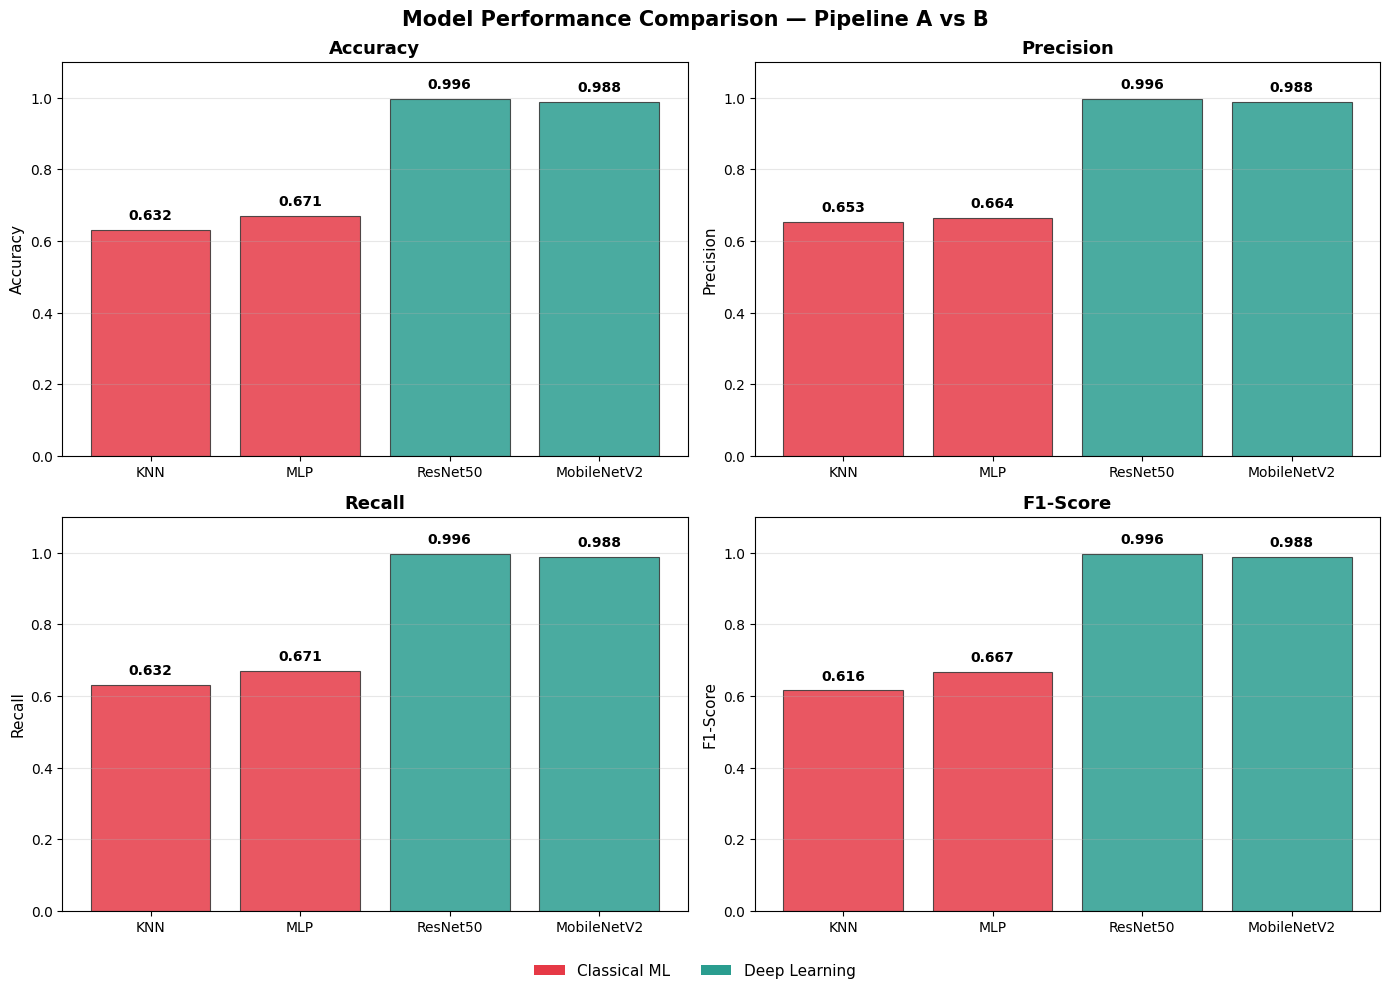

model_comparison.png saved


In [18]:
# CELL 15 ─ Visualisation 1: Bar comparison

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = summary_df['Model'].tolist()          # FIX: was `models` (shadowed import)
colors    = ['#E63946' if p == 'Classical ML' else '#2A9D8F'
             for p in summary_df['Pipeline']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison — Pipeline A vs B', fontsize=15, fontweight='bold')

for ax, metric in zip(axes.flat, metrics):
    vals = summary_df[metric].values
    bars = ax.bar(model_names, vals, color=colors, alpha=0.85, edgecolor='#333', linewidth=0.8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#E63946', label='Classical ML'),
                Patch(facecolor='#2A9D8F', label='Deep Learning')]
fig.legend(handles=legend_elems, loc='lower center', ncol=2, fontsize=11, frameon=False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('model_comparison.png saved')

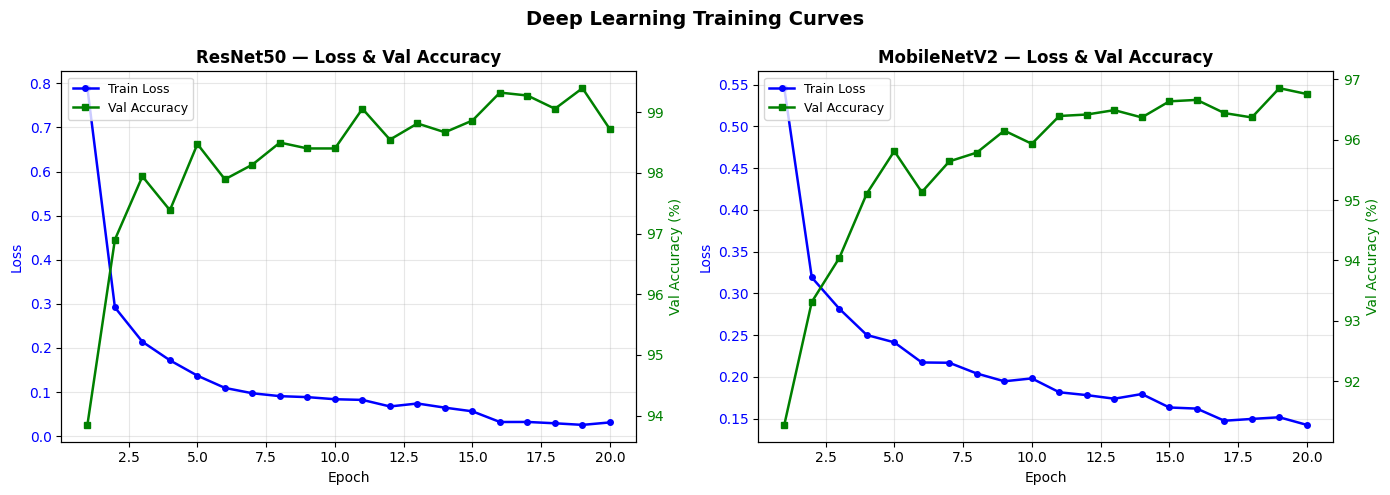

✓ training_curves.png saved


In [19]:
# CELL 16 ─ Visualisation 2: Training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deep Learning Training Curves', fontsize=14, fontweight='bold')

for ax, (name, hist) in zip(axes, [('ResNet50', hist_resnet), ('MobileNetV2', hist_mobile)]):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], 'b-o', ms=4, lw=1.8, label='Train Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title(f'{name} — Loss & Val Accuracy', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_acc'], 'g-s', ms=4, lw=1.8, label='Val Accuracy')
    ax2.set_ylabel('Val Accuracy (%)', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    lines  = ax.get_lines()  + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ training_curves.png saved')

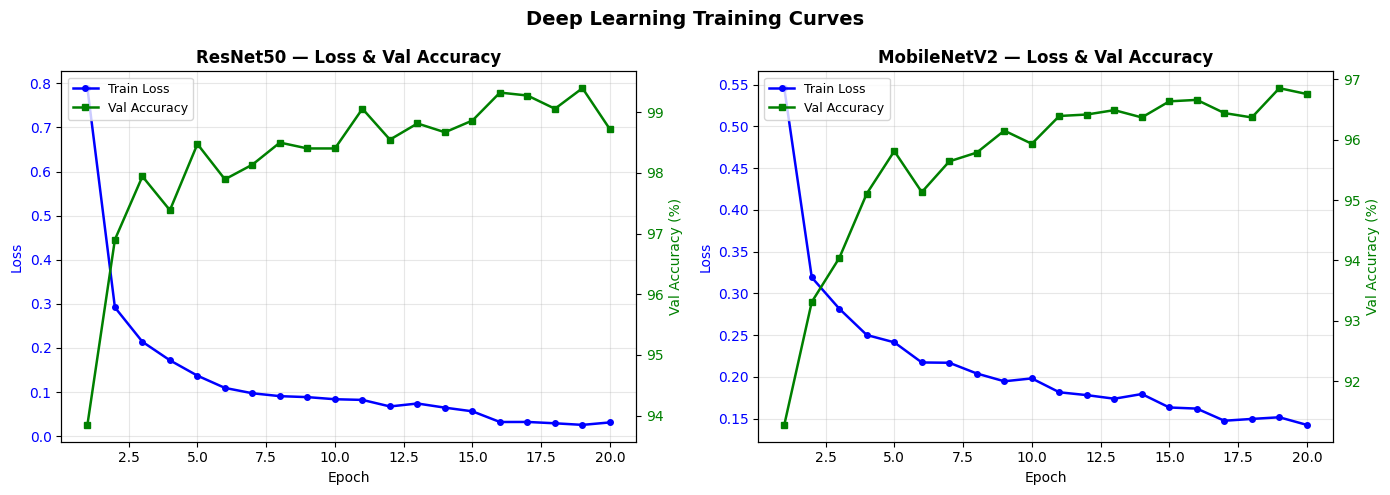

training_curves.png saved


In [20]:
# CELL 16 ─ Visualisation 2: Training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deep Learning Training Curves', fontsize=14, fontweight='bold')

for ax, (name, hist) in zip(axes, [('ResNet50', hist_resnet), ('MobileNetV2', hist_mobile)]):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], 'b-o', ms=4, lw=1.8, label='Train Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title(f'{name} — Loss & Val Accuracy', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_acc'], 'g-s', ms=4, lw=1.8, label='Val Accuracy')
    ax2.set_ylabel('Val Accuracy (%)', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    lines  = ax.get_lines()  + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('training_curves.png saved')

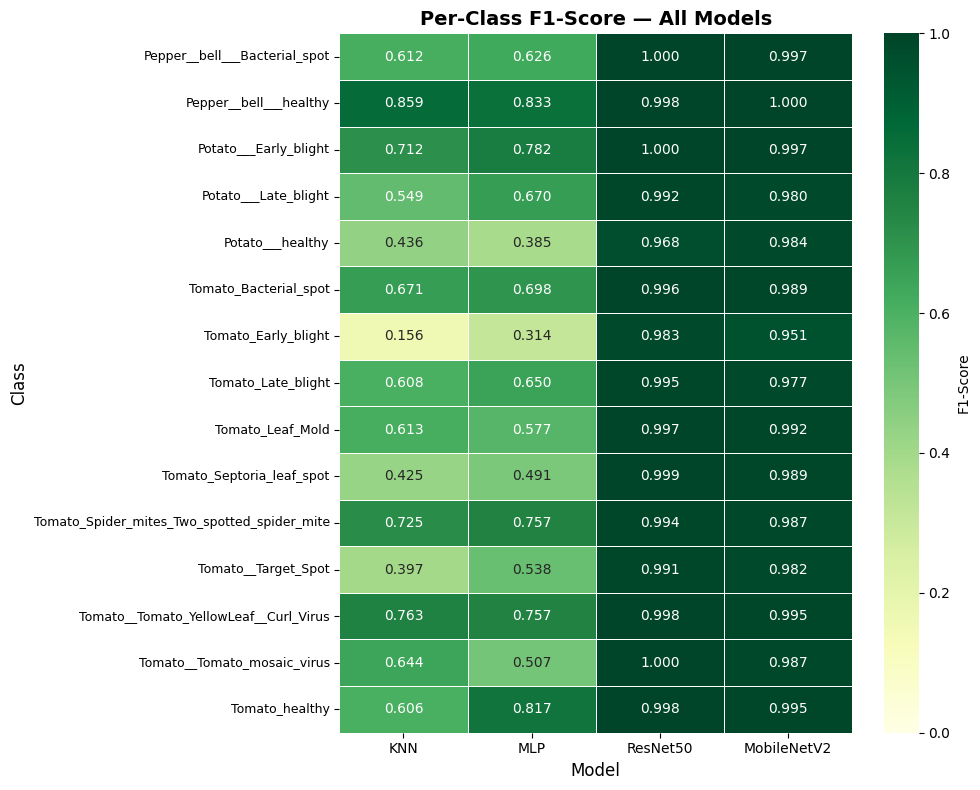

✓ per_class_f1_heatmap.png saved


In [21]:
# CELL 18 ─ Visualisation 4: Per-Class F1 Heatmap

f1_matrix = pd.DataFrame(
    {name: res['per_class'].iloc[:-1]['F1-Score'].values   # drop summary row
     for name, res in ALL_MODELS.items()},
    index=CLASSES
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5, cbar_kws={'label': 'F1-Score'})
ax.set_title('Per-Class F1-Score — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Class', fontsize=12)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ per_class_f1_heatmap.png saved')

In [22]:
# CELL 19 ─ Save All Models & Artefacts

out_dir = Path('plant_disease_results')
out_dir.mkdir(exist_ok=True)

# Classical ML
with open(out_dir / 'knn_model.pkl',   'wb') as f: pickle.dump(knn,       f)
with open(out_dir / 'mlp_model.pkl',   'wb') as f: pickle.dump(mlp,       f)
with open(out_dir / 'scaler_ml.pkl',   'wb') as f: pickle.dump(scaler_ml, f)
with open(out_dir / 'pca.pkl',         'wb') as f: pickle.dump(pca,       f)

# PyTorch
torch.save(resnet50.state_dict(),  out_dir / 'resnet50.pth')
torch.save(mobilenet.state_dict(), out_dir / 'mobilenetv2.pth')

# Class mapping
with open(out_dir / 'class_mapping.json', 'w') as f:
    json.dump({'class_to_idx': CLASS_TO_IDX, 'idx_to_class': IDX_TO_CLASS}, f, indent=2)

# Per-class metrics CSVs
for name, res in ALL_MODELS.items():
    res['per_class'].to_csv(out_dir / f'{name}_per_class_metrics.csv', index=False)

summary_df.to_csv(out_dir / 'results_summary.csv', index=False)

print(f'All artefacts saved to {out_dir.resolve()}/')
print('\nFiles:')
for f in sorted(out_dir.iterdir()): print(f'  {f.name}')

All artefacts saved to C:\Users\chira\Installation\CV Project\plant_disease_results/

Files:
  class_mapping.json
  knn_model.pkl
  KNN_per_class_metrics.csv
  mlp_model.pkl
  MLP_per_class_metrics.csv
  mobilenetv2.pth
  MobileNetV2_per_class_metrics.csv
  pca.pkl
  resnet50.pth
  ResNet50_per_class_metrics.csv
  results_summary.csv
  scaler_ml.pkl


  Selected Image : c07db642-c675-4066-99b6-56bc8207fb37___RS_HL 4164.JPG
  True Class     : Potato___healthy

Model           Predicted Class                               Confidence  Correct/Wrong
--------------------------------------------------------------------------------
KNN             Tomato__Tomato_YellowLeaf__Curl_Virus             40.00%  Wrong
MLP             Potato___healthy                                  99.90%  Correct
ResNet50        Potato___healthy                                 100.00%  Correct
MobileNetV2     Potato___healthy                                  99.99%  Correct
--------------------------------------------------------------------------------


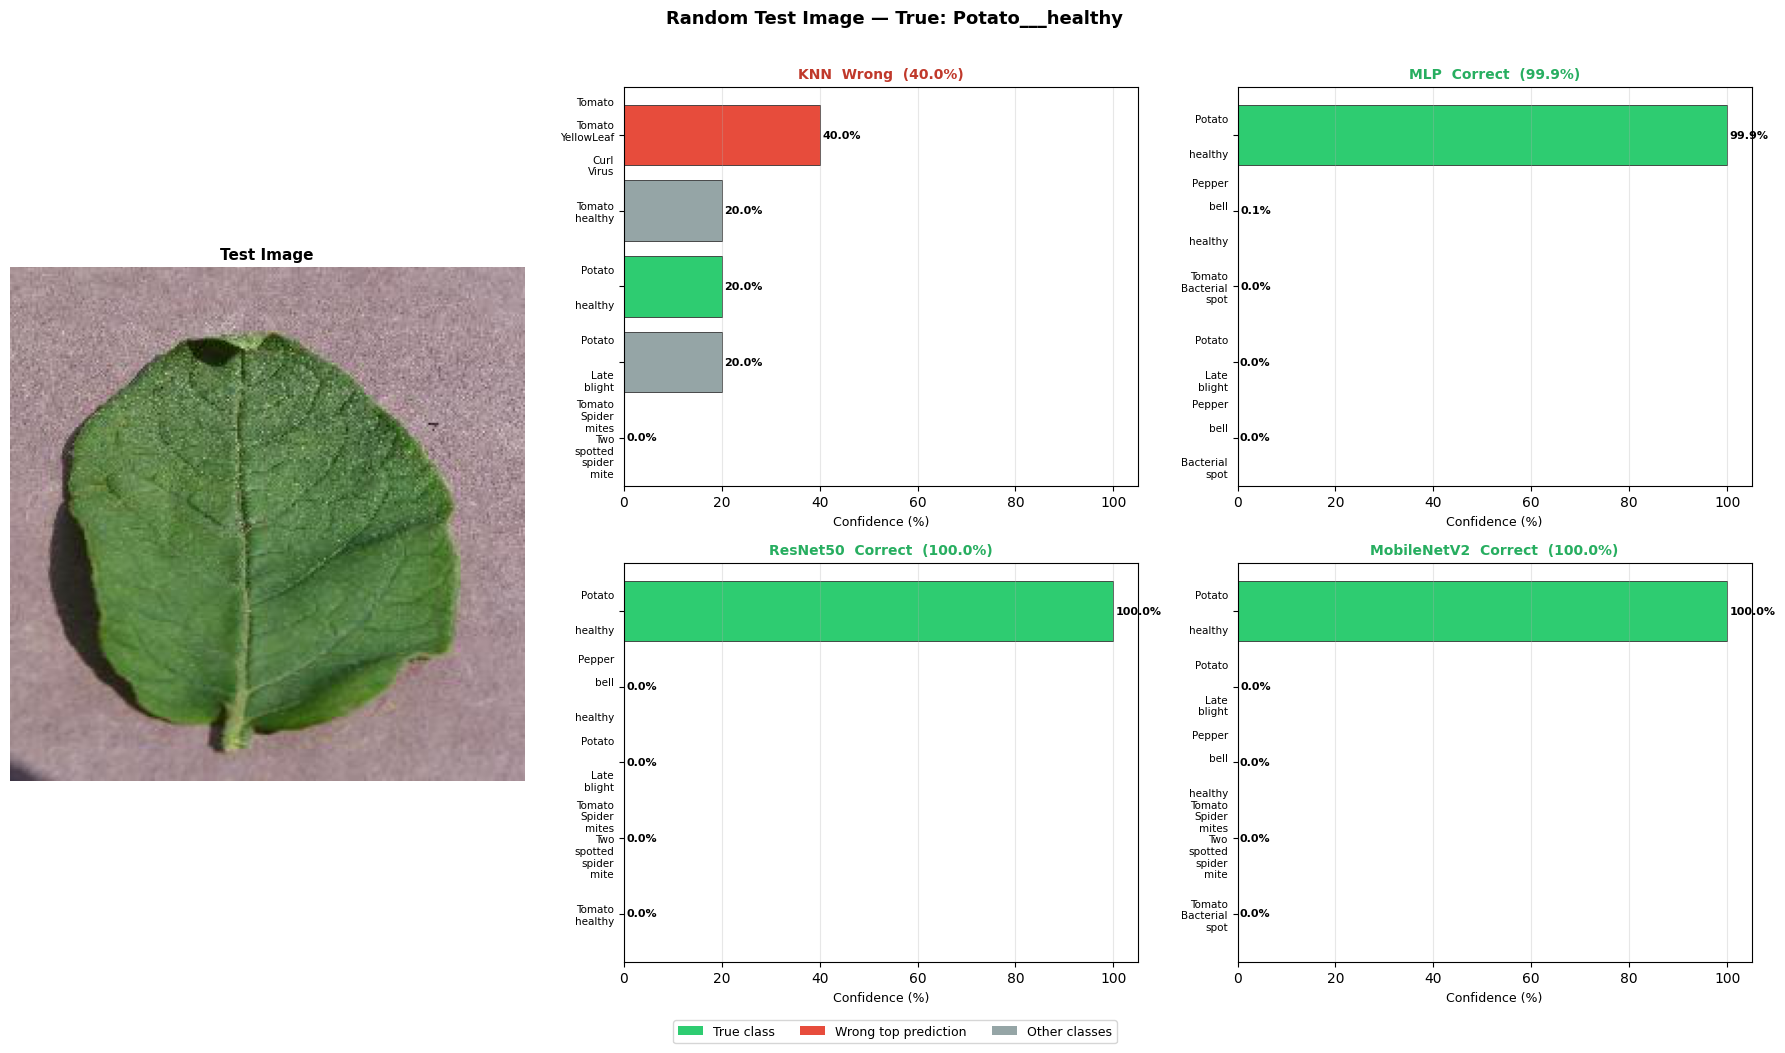


 random_test_result.png saved


In [23]:
# CELL 20 — Random Image Prediction Test (All 4 Models)

import random
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def predict_single_image(img_path, true_label):
    """
    Runs all 4 models on a single image and returns predictions + confidence.
    """
    results = {}

    #1. Classical ML (KNN & MLP)
    img_gray = Image.open(img_path).convert('L').resize(ML_IMG_SIZE)
    x_raw    = np.array(img_gray, dtype=np.uint8).flatten().reshape(1, -1)

    # HOG → Scale → PCA
    from skimage.feature import hog as skimage_hog
    hog_feat = np.array([skimage_hog(
                    np.array(img_gray, dtype=np.uint8),
                    **HOG_PARAMS)])
    x_sc  = scaler_ml.transform(hog_feat)
    x_pca = pca.transform(x_sc)

    # KNN — no probability calibration by default; use predict_proba with n_neighbors
    knn_proba  = knn.predict_proba(x_pca)[0]
    knn_pred   = int(np.argmax(knn_proba))
    knn_conf   = float(knn_proba[knn_pred])
    results['KNN'] = {
        'pred'  : IDX_TO_CLASS[knn_pred],
        'conf'  : knn_conf,
        'correct': knn_pred == CLASS_TO_IDX[true_label],
        'proba' : knn_proba
    }

    # MLP
    mlp_proba  = mlp.predict_proba(x_pca)[0]
    mlp_pred   = int(np.argmax(mlp_proba))
    mlp_conf   = float(mlp_proba[mlp_pred])
    results['MLP'] = {
        'pred'  : IDX_TO_CLASS[mlp_pred],
        'conf'  : mlp_conf,
        'correct': mlp_pred == CLASS_TO_IDX[true_label],
        'proba' : mlp_proba
    }

    #2. Deep Learning (ResNet50 & MobileNetV2) 
    img_rgb = Image.open(img_path).convert('RGB')
    tensor  = test_transform(img_rgb).unsqueeze(0).to(DEVICE)

    for model_name, model_obj in [('ResNet50', resnet50), ('MobileNetV2', mobilenet)]:
        model_obj.eval()
        with torch.no_grad():
            logits = model_obj(tensor)
            proba  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_idx = int(np.argmax(proba))
        conf     = float(proba[pred_idx])
        results[model_name] = {
            'pred'   : IDX_TO_CLASS[pred_idx],
            'conf'   : conf,
            'correct': pred_idx == CLASS_TO_IDX[true_label],
            'proba'  : proba
        }

    return results


def run_random_test(n_top=5):
    """
    Picks a random image from the dataset, runs all models, and plots results.
    """
    #Pick a random image 
    true_label  = random.choice(CLASSES)
    img_folder  = DATA_ROOT / true_label
    img_path    = random.choice(list(img_folder.glob('*.*')))

    print(f"{'='*65}")
    print(f"  Selected Image : {img_path.name}")
    print(f"  True Class     : {true_label}")
    print(f"{'='*65}")

    results = predict_single_image(img_path, true_label)

    #Console summary 
    print(f"\n{'Model':<15} {'Predicted Class':<45} {'Confidence':>10}  {'Correct/Wrong':>4}")
    print(f"{'-'*80}")
    for model_name, r in results.items():
        tick   = 'Correct' if r['correct'] else 'Wrong'
        conf_pct = f"{r['conf']*100:.2f}%"
        print(f"{model_name:<15} {r['pred']:<45} {conf_pct:>10}  {tick:>4}")
    print(f"{'-'*80}")

    #Plot 
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f"Random Test Image — True: {true_label}", 
                 fontsize=13, fontweight='bold', y=1.01)

    # Col 1: the test image
    ax_img = fig.add_subplot(2, 3, (1, 4))   
    ax_img.imshow(Image.open(img_path).convert('RGB'))
    ax_img.set_title("Test Image", fontsize=11, fontweight='bold')
    ax_img.axis('off')
    # True label banner
    ax_img.set_xlabel(f"True: {true_label}", fontsize=10,
                      color='green', fontweight='bold')

    # Cols 2-3: top-N confidence bar charts per model
    model_order = ['KNN', 'MLP', 'ResNet50', 'MobileNetV2']
    positions   = [2, 3, 5, 6]

    for pos, model_name in zip(positions, model_order):
        r      = results[model_name]
        proba  = r['proba']

        # Top-N classes by confidence
        top_idx   = np.argsort(proba)[::-1][:n_top]
        top_confs = proba[top_idx] * 100
        top_names = [IDX_TO_CLASS[i].replace('_', '\n') for i in top_idx]

        ax = fig.add_subplot(2, 3, pos)
        colors = ['#2ecc71' if IDX_TO_CLASS[i] == true_label else
                  '#e74c3c' if i == top_idx[0] and IDX_TO_CLASS[i] != true_label else
                  '#95a5a6'
                  for i in top_idx]

        bars = ax.barh(range(n_top), top_confs[::-1], color=colors[::-1],
                       edgecolor='#333', linewidth=0.6)
        ax.set_yticks(range(n_top))
        ax.set_yticklabels(top_names[::-1], fontsize=7.5)
        ax.set_xlabel('Confidence (%)', fontsize=9)
        ax.set_xlim(0, 105)
        ax.grid(axis='x', alpha=0.3)

        # Confidence labels on bars
        for bar, val in zip(bars, top_confs[::-1]):
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

        tick = 'Correct' if r['correct'] else 'Wrong'
        title_color = '#27ae60' if r['correct'] else '#c0392b'
        ax.set_title(f"{model_name}  {tick}  ({r['conf']*100:.1f}%)",
                     fontsize=10, fontweight='bold', color=title_color)

    # Legend
    legend_elems = [
        mpatches.Patch(facecolor='#2ecc71', label='True class'),
        mpatches.Patch(facecolor='#e74c3c', label='Wrong top prediction'),
        mpatches.Patch(facecolor='#95a5a6', label='Other classes'),
    ]
    fig.legend(handles=legend_elems, loc='lower center',
               ncol=3, fontsize=9, frameon=True,
               bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout()
    plt.savefig('random_test_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n random_test_result.png saved')



run_random_test(n_top=5)